# Mejora 4 - Modelo en dos etapas + SVM lineal

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

Hasta ahora el proyecto tiene varios modelos candidatos: la regresión logística por bloques del notebook principal, el modelo en dos etapas por oración (Mejora 1), la regresión logística con ajuste fino (Mejora 3) y los modelos del notebook `Exploracion_modelos_alternativos`, entre ellos un apilamiento de regresión logística, Naive Bayes y SVM lineal. Sus puntajes públicos en Kaggle fueron:

| Envío | Puntaje público |
|:---|:---:|
| `submission_regresion_logistica_ajuste_fino.csv` | 0,90666 |
| `submission_regresion_logistica_bloques.csv` (modelo actual) | 0,90222 |
| `submission_regresion_logistica_cv_repetida.csv` | 0,90222 |
| `submission_dos_etapas_por_oracion.csv` | 0,90222 |
| `submission_exploracion_apilamiento.csv` | 0,90000 |
| `submission_dos_etapas_svm.csv` (este notebook, enviado después) | 0,89888 |

Estos puntajes son muy parecidos entre sí y, como se muestra en la sección 10, se calculan sobre pocas reseñas. Por eso este notebook compara los modelos de una forma más confiable (sección 8) y propone un modelo que junta las dos ideas que mejor funcionaron: **el modelo en dos etapas por oración y la SVM lineal del apilamiento**.

Como el puntaje de Kaggle es la exactitud (ver sección 10), en este notebook la métrica principal es la exactitud.

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Todo se basa en TF-IDF y n-gramas. |
| Usar únicamente modelos de scikit-learn. | Los modelos que componen el sistema son `LogisticRegression`, `MultinomialNB` y `LinearSVC`. La clase `ModeloDosEtapas` solo los encadena con la interfaz de scikit-learn. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 14). |

`LinearSVC` y el apilamiento son modelos clásicos de scikit-learn, pero no hicieron parte del material del curso.

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_val_score, train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
NOMBRE_MODELO = 'dos_etapas_svm'

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos y partición

Se usan los mismos datos, la misma partición 80/20 estratificada (semilla 42) y las mismas 5 particiones de validación cruzada de los notebooks anteriores.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
print('Distribución de clases en train:')
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Distribución de clases en train:


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


In [3]:
X = train[['text']]
y = train['label']

# Misma partición y mismas particiones de validación cruzada que en el notebook principal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

Entrenamiento: (9600, 1) | Prueba: (2400, 1)


## 3. Preprocesamiento y modelo actual de referencia

In [4]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [5]:
def metricas(y_real, y_pred):
    return {'Exactitud': accuracy_score(y_real, y_pred),
            'Precisión (macro)': precision_score(y_real, y_pred, average='macro'),
            'Recall (macro)': recall_score(y_real, y_pred, average='macro'),
            'F1 (macro)': f1_score(y_real, y_pred, average='macro')}

In [6]:
# Modelo actual (el del notebook principal): regresión logística L1 sobre la representación por bloques
modelo_actual = Pipeline([
    ('rep', construir_representacion()),
    ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)),
])
modelo_actual.fit(X_train, y_train)
pred_actual = pd.Series(modelo_actual.predict(X_test), index=y_test.index)

cv_actual = cross_val_score(modelo_actual, X_train, y_train, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f'Modelo actual - F1-macro en validación cruzada (train): {cv_actual.mean():.4f} +/- {cv_actual.std():.4f}')
pd.DataFrame({'Modelo actual (test)': metricas(y_test, pred_actual)}).T.round(4)

Modelo actual - F1-macro en validación cruzada (train): 0.8992 +/- 0.0072


,Exactitud,Precisión (macro),Recall (macro),F1 (macro)
Modelo actual (test),0.8946,0.8987,0.8998,0.8993


## 4. La idea: juntar el modelo por oración con la SVM del apilamiento

En una comparación de todos los modelos con las mismas particiones (sección 8), los dos que más mejoraban al modelo actual eran el modelo en dos etapas por oración y el apilamiento. Ambos mejoran por razones distintas:

- El **modelo en dos etapas** puntúa cada trozo de la reseña y aprende, por ejemplo, a mirar la última opinión aunque la reseña termine con un comentario neutro.
- El **apilamiento** combina tres clasificadores de texto distintos (regresión logística, Naive Bayes y SVM lineal), y la SVM aporta una frontera de decisión diferente a la de la regresión logística.

El modelo en dos etapas ya usaba las probabilidades de la regresión logística y de Naive Bayes como atributos de su etapa 2, pero no la SVM. La idea de este notebook es agregarle a la etapa 2 **la salida de la SVM lineal** (un puntaje por clase), para aprovechar las dos fuentes de mejora en un solo modelo.

## 5. El modelo

Se reutiliza la clase `ModeloDosEtapas` de la Mejora 1 con dos cambios:

- Un hiperparámetro `usar_svm`. Con `usar_svm=True` se entrena además una SVM lineal (`LinearSVC`, `C = 0,3`, el valor elegido en el notebook de exploración) sobre la representación por bloques, y sus tres puntajes se agregan como atributos de la etapa 2 (57 atributos en vez de 54). Con `usar_svm=False` el modelo es exactamente el de la Mejora 1, lo que permite compararlos en este mismo notebook.
- Un hiperparámetro `C_svm` para la regularización de esa SVM.

Como en la Mejora 1, los atributos con los que se entrena la etapa 2 se calculan fuera de muestra, con una validación cruzada interna de 5 particiones.

In [7]:
def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    # Comienzos de oración más repetidos (sin contar la primera oración)
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]

In [8]:
class ModeloDosEtapas(ClassifierMixin, BaseEstimator):
    """Clasificador de reseñas en dos etapas.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de ser negativo, neutral o positivo).
    Etapa 2: regresión logística que decide la etiqueta usando los puntajes de los últimos trozos,
    las salidas de los modelos por bloques (regresión logística, Naive Bayes y, si usar_svm=True,
    SVM lineal) y el comienzo de las oraciones con opinión.
    Con usar_svm=False es exactamente el modelo del notebook Mejora 1.
    """

    def __init__(self, C_etapa1=3, C_etapa2=0.1, C_svm=0.3, usar_svm=True, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_svm = C_svm
        self.usar_svm = usar_svm
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        # Modelos por bloques: regresión logística y Naive Bayes (y SVM lineal si se pide)
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion().fit(datos)
        matriz = representacion.transform(datos)
        comp = {'representacion': representacion,
                'regresion': LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                random_state=RANDOM_STATE).fit(matriz, etiquetas),
                'bayes': MultinomialNB(alpha=0.3).fit(matriz, etiquetas)}
        if self.usar_svm:
            comp['svm'] = LinearSVC(C=self.C_svm, random_state=RANDOM_STATE).fit(matriz, etiquetas)
        # Etapa 1
        comp['vectorizador'], comp['clasificador'] = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return comp

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)

        # Se puntúan de una sola vez todos los trozos y todas las oraciones de todos los textos
        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):          # los últimos trozos: 3 probabilidades + marca de conector
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]

            polaridad = P[:, 2] - P[:, 0]               # P(positivo) - P(negativo)
            con_opinion = np.where(P[:, 1] < 0.5)[0]    # trozos que no parecen neutrales
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]

            fila += list(prob_bayes[k])
            # Comienzo de las dos últimas oraciones con opinión
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            filas.append(fila)

        caracteristicas = np.array(filas)
        if self.usar_svm:
            # Salida de la SVM lineal: un puntaje por clase (distancia al hiperplano)
            caracteristicas = np.hstack([caracteristicas, comp['svm'].decision_function(matriz)])
        return caracteristicas

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Los atributos con los que se entrena la etapa 2 se calculan "fuera de muestra":
        # cada reseña se puntúa con modelos que no la vieron al entrenarse.
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)

        # Para predecir reseñas nuevas, los componentes se entrenan con todos los datos
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        self.nombres_caracteristicas_ = self._nombres()
        return self

    def _nombres(self):
        nombres = ['regresion_neg', 'regresion_neu', 'regresion_pos']
        for j in range(1, K_ULTIMOS + 1):
            nombres += [f'trozo-{j}_neg', f'trozo-{j}_neu', f'trozo-{j}_pos', f'trozo-{j}_tras_conector']
        nombres += ['polaridad_ultima_opinion', 'polaridad_penultima_opinion', 'polaridad_primera_opinion',
                    'n_trozos_con_opinion', 'max_prob_pos', 'max_prob_neg', 'media_prob_neu', 'n_trozos']
        nombres += ['bayes_neg', 'bayes_neu', 'bayes_pos']
        nombres += [f'ultima_opinion_inicia_con:{c}' for c in self.comienzos_]
        nombres += [f'penultima_opinion_inicia_con:{c}' for c in self.comienzos_]
        if self.usar_svm:
            nombres += ['svm_neg', 'svm_neu', 'svm_pos']
        return nombres

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

## 6. Búsqueda de hiperparámetros

De la Mejora 1 se mantiene `C_etapa1 = 3`. Como la etapa 2 ahora tiene tres atributos más, se vuelve a buscar su regularización (`C_etapa2`) con la misma validación cruzada de los notebooks anteriores, esta vez usando la exactitud como métrica.

In [9]:
grilla = {'C_etapa2': [0.03, 0.1, 0.3]}     # regularización de la etapa 2, que ahora tiene 3 atributos más

busqueda = GridSearchCV(ModeloDosEtapas(usar_svm=True), grilla, cv=kfold, scoring='accuracy', n_jobs=-1)
busqueda.fit(X_train, y_train)

cv_actual_acc = cross_val_score(modelo_actual, X_train, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
print('Mejores hiperparámetros:', busqueda.best_params_)
print(f'Exactitud en validación cruzada: {busqueda.best_score_:.4f}   (modelo actual: {cv_actual_acc.mean():.4f})')

resultados = pd.DataFrame(busqueda.cv_results_)
resultados[['param_C_etapa2', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').round(4)

Mejores hiperparámetros: {'C_etapa2': 0.03}
Exactitud en validación cruzada: 0.8994   (modelo actual: 0.8948)


,param_C_etapa2,mean_test_score,std_test_score,rank_test_score
0,0.03,0.8994,0.0078,1
2,0.30,0.8988,0.0076,2
1,0.10,0.8986,0.0076,3


La mejor configuración usa `C_etapa2 = 0,03`, con una exactitud en validación cruzada de 0,8994 frente a 0,8948 del modelo actual (+0,46 puntos). Las tres configuraciones quedan entre 0,8986 y 0,8994, así que la elección de `C_etapa2` casi no importa.

## 7. Evaluación en el conjunto de prueba

,Exactitud,Precisión (macro),Recall (macro),F1 (macro)
Modelo actual,0.8946,0.8987,0.8998,0.8993
Dos etapas (Mejora 1),0.8971,0.9021,0.9021,0.9021
Dos etapas + SVM,0.8988,0.9037,0.9037,0.9036


              precision    recall  f1-score   support

    negativo      0.849     0.872     0.860       843
     neutral      0.994     0.997     0.996       715
    positivo      0.868     0.842     0.855       842

    accuracy                          0.899      2400
   macro avg      0.904     0.904     0.904      2400
weighted avg      0.899     0.899     0.899      2400



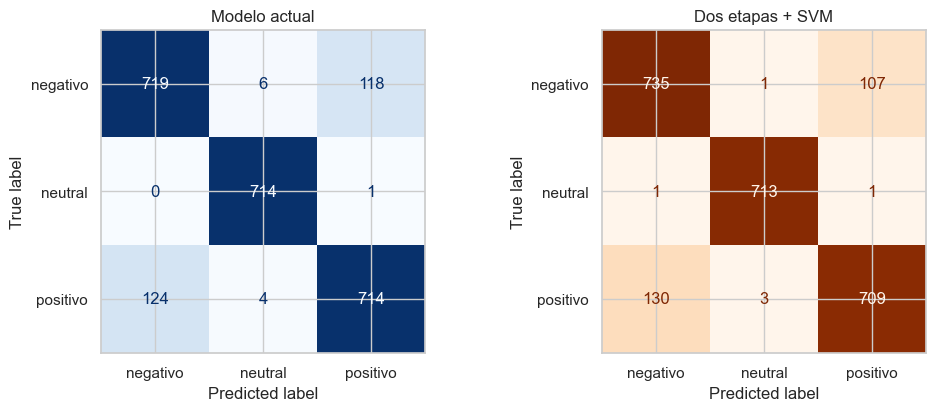

In [10]:
mejor_modelo = busqueda.best_estimator_
pred_svm = pd.Series(mejor_modelo.predict(X_test), index=y_test.index)

# Mismo modelo sin la SVM (es el de la Mejora 1), entrenado con los mismos datos
modelo_sin_svm = clone(mejor_modelo).set_params(usar_svm=False, C_etapa2=0.1).fit(X_train, y_train)
pred_sin_svm = pd.Series(modelo_sin_svm.predict(X_test), index=y_test.index)

display(pd.DataFrame({'Modelo actual': metricas(y_test, pred_actual),
                      'Dos etapas (Mejora 1)': metricas(y_test, pred_sin_svm),
                      'Dos etapas + SVM': metricas(y_test, pred_svm)}).T.round(4))
print(classification_report(y_test, pred_svm, digits=3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, pred_actual, labels=ORDEN_CLASES, cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Modelo actual')
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm, labels=ORDEN_CLASES, cmap='Oranges', ax=ax[1], colorbar=False)
ax[1].set_title('Dos etapas + SVM')
plt.show()

En el conjunto de prueba el modelo nuevo obtiene una exactitud de 0,8988 y un F1-macro de 0,9036. Eso es +0,42 puntos de exactitud frente al modelo actual (0,8946) y +0,17 frente al modelo en dos etapas sin SVM (0,8971). La mejora está sobre todo en `negativo` (F1 de 0,860 contra 0,853 del modelo actual).

Con 2.400 reseñas, esas diferencias equivalen a unas 10 reseñas frente al modelo actual y unas 4 frente a la Mejora 1. Son demasiado pocas para concluir con un solo conjunto de prueba, por eso la sección siguiente compara con 15 particiones.

## 8. Comparación justa con los demás modelos (15 particiones)

Los resultados de los notebooks anteriores no son del todo comparables entre sí: cada modelo se evaluó con una partición de prueba de 2.400 reseñas, donde una diferencia de 0,3 puntos son unas 7 reseñas. Para compararlos de forma justa, aquí se entrenan y evalúan los cuatro candidatos principales **sobre las mismas 15 particiones** (3 repeticiones de validación cruzada de 5 particiones, semillas 1, 2 y 3) de las 12.000 reseñas etiquetadas. Como todos se evalúan en las mismas particiones, se pueden comparar partición por partición.

In [11]:
# Apilamiento del notebook Exploracion_modelos_alternativos (misma configuración)
def lr_l1():
    return LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)


apilamiento = Pipeline([
    ('rep', construir_representacion()),
    ('modelo', StackingClassifier([('lr', lr_l1()), ('nb', MultinomialNB(alpha=0.5)),
                                   ('svm', LinearSVC(C=0.3, random_state=RANDOM_STATE))],
                                  final_estimator=LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), cv=5)),
])

candidatos = {
    'Modelo actual (regresión logística)': modelo_actual,
    'Apilamiento (exploración)': apilamiento,
    'Dos etapas (Mejora 1)': ModeloDosEtapas(usar_svm=False, C_etapa2=0.1),
    'Dos etapas + SVM (Mejora 4)': ModeloDosEtapas(usar_svm=True, C_etapa2=busqueda.best_params_['C_etapa2']),
}

# 3 repeticiones de validación cruzada de 5 particiones sobre las 12.000 reseñas etiquetadas
particiones = []
for semilla in [1, 2, 3]:
    particiones += list(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X, y))

exactitudes = {}
for nombre, modelo in candidatos.items():
    exactitudes[nombre] = cross_val_score(clone(modelo), X, y, cv=particiones, scoring='accuracy', n_jobs=-1)

referencia = exactitudes['Modelo actual (regresión logística)']
filas = []
for nombre, valores in exactitudes.items():
    diferencia = valores - referencia
    filas.append({'Modelo': nombre, 'Exactitud media': valores.mean(), 'Desviación': valores.std(ddof=1),
                  'Diferencia vs actual': diferencia.mean(),
                  'Error estándar de la diferencia': diferencia.std(ddof=1) / np.sqrt(len(diferencia)),
                  'Mejora en (de 15)': int((diferencia > 0).sum())})
tabla_justa = pd.DataFrame(filas).set_index('Modelo').sort_values('Exactitud media', ascending=False)
tabla_justa.round(4)

,Exactitud media,Desviación,Diferencia vs actual,Error estándar de la diferencia,Mejora en (de 15)
Modelo,,,,,
Dos etapas + SVM (Mejora 4),0.9009,0.0055,0.0042,0.0008,14
Dos etapas (Mejora 1),0.8997,0.0051,0.0031,0.0009,12
Apilamiento (exploración),0.8991,0.0059,0.0025,0.0006,13
Modelo actual (regresión logística),0.8966,0.0062,0.0000,0.0000,0


In [12]:
nuevo = exactitudes['Dos etapas + SVM (Mejora 4)']
for rival in ['Apilamiento (exploración)', 'Dos etapas (Mejora 1)']:
    diferencia = nuevo - exactitudes[rival]
    print(f'Dos etapas + SVM vs {rival}: diferencia media {diferencia.mean():+.4f} '
          f'(error estándar {diferencia.std(ddof=1) / np.sqrt(len(diferencia)):.4f}), mejora en {(diferencia > 0).sum()} de 15 particiones')

Dos etapas + SVM vs Apilamiento (exploración): diferencia media +0.0017 (error estándar 0.0009), mejora en 9 de 15 particiones
Dos etapas + SVM vs Dos etapas (Mejora 1): diferencia media +0.0011 (error estándar 0.0007), mejora en 8 de 15 particiones


- **Frente al modelo actual la mejora es clara.** El modelo nuevo tiene la exactitud media más alta (0,9009), con +0,42 puntos frente al modelo actual, un error estándar de 0,08 puntos y mejor resultado en 14 de las 15 particiones. El modelo en dos etapas (+0,31, 12 de 15) y el apilamiento (+0,25, 13 de 15) también mejoran al modelo actual.
- **Entre los tres mejores no hay un ganador claro.** El modelo nuevo supera al apilamiento por 0,17 puntos (gana en 9 de 15) y al de dos etapas por 0,11 puntos (gana en 8 de 15). Son diferencias del tamaño del ruido, así que en la práctica los tres son equivalentes, aunque el modelo nuevo tiene el mejor promedio.
- **El apilamiento se veía mejor de lo que es.** En el notebook de exploración tuvo una exactitud de 0,9000 en su conjunto de prueba; con 15 particiones queda en 0,8991. Esa partición le era un poco favorable.

## 9. ¿Dónde se sigue equivocando?

Para entender cuánto margen de mejora queda, se clasifican las reseñas en grupos y se mide la exactitud del modelo nuevo en cada uno, con una predicción por reseña (validación cruzada de 5 particiones):

- **Neutral.**
- **Termina en un cierre ambiguo:** reseñas positivas o negativas cuya última oración es una frase repetida 12 o más veces en los datos, como "cada quien que juzgue" o "en fin, ni fu ni fa".
- **Conector aditivo:** alguna oración empieza con "por otro lado", "de paso", "por cierto" o "además".
- **Conector adversativo:** la reseña tiene "pero", "aunque", "aun así", "eso sí", etc.
- **Sin conector de contraste:** el resto.

In [13]:
# Una predicción por reseña: validación cruzada de 5 particiones (primera repetición)
pred_cv = pd.Series(cross_val_predict(clone(candidatos['Dos etapas + SVM (Mejora 4)']), X, y,
                                      cv=particiones[:5], n_jobs=-1), index=y.index)
acierto = pred_cv == y


def clave_oracion(oracion):
    return re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).strip()


finales = Counter(clave_oracion(separar_oraciones(t)[-1]) for t in X['text'])
cierres = {o for o, n in finales.items() if n >= 12}
termina_en_cierre = X['text'].map(lambda t: clave_oracion(separar_oraciones(t)[-1]) in cierres)

ADITIVOS = ('por otro', 'de paso', 'por cierto', 'ademas')


def tipo_de_resena(texto, etiqueta, cierre):
    if etiqueta == 'neutral':
        return 'Neutral'
    if cierre:
        return 'Termina en un cierre ambiguo'
    comienzos = [comienzo_oracion(o) for o in separar_oraciones(texto)[1:]]
    if any(c.startswith(a) for c in comienzos for a in ADITIVOS):
        return 'Conector aditivo (por otro lado, de paso, por cierto, además)'
    if re.search(r'\b(pero|aunque|aun asi|con todo|al final|eso si|ahora|en cambio)\b', quitar_tildes(texto.lower())):
        return 'Conector adversativo (pero, aunque, aun así, eso sí...)'
    return 'Sin conector de contraste'


tipo = pd.Series([tipo_de_resena(t, e, c) for t, e, c in zip(X['text'], y, termina_en_cierre)], index=y.index)
resumen_errores = pd.DataFrame({'reseñas': tipo.value_counts(),
                                'exactitud': acierto.groupby(tipo).mean(),
                                'errores': (~acierto).groupby(tipo).sum()})
resumen_errores['% de los errores'] = resumen_errores['errores'] / resumen_errores['errores'].sum() * 100
resumen_errores.sort_values('errores', ascending=False).round(3)

,reseñas,exactitud,errores,% de los errores
Termina en un cierre ambiguo,934,0.499,468,39.130
"Conector adversativo (pero, aunque, aun así, eso sí...)",3717,0.921,293,24.498
"Conector aditivo (por otro lado, de paso, por cierto, además)",1212,0.822,216,18.060
Sin conector de contraste,2561,0.919,208,17.391
Neutral,3576,0.997,11,0.920


- **Cierres ambiguos:** son el 39% de los errores (468). En ese grupo el modelo acierta el 49,9% de las veces, lo mismo que adivinar entre positivo y negativo; como se vio en los notebooks anteriores, el texto no parece tener información para decidir.
- **Conector aditivo:** es el grupo con la exactitud más baja fuera de los cierres (0,822, con 216 errores). Es coherente con que un conector como "por otro lado" no indica cuál de las dos opiniones domina.
- **Conector adversativo y sin conector:** quedan alrededor de 0,92. **Neutral:** casi perfecto (0,997).

Si los cierres ambiguos no se pueden resolver, la exactitud máxima posible estaría cerca de 0,96 (fallar solo esos 468 de 12.000). Esa es una cota teórica, porque exigiría acertar todo lo demás, y parte de los errores con conector aditivo probablemente también son ambiguos. El modelo está en 0,90: el margen que queda no es fácil de capturar con estas técnicas.

## 10. Lectura de los puntajes públicos de Kaggle

Los puntajes públicos de Kaggle son la proporción de aciertos sobre una parte de `eval.csv`. Si esa parte tiene `n` reseñas, cada puntaje debería ser un número de aciertos dividido por `n`. Buscando el menor `n` que hace enteros a todos los puntajes se puede saber con cuántas reseñas se calculan.

In [14]:
puntajes_publicos = {
    'submission_regresion_logistica_ajuste_fino.csv': 0.90666,
    'submission_regresion_logistica_bloques.csv (modelo actual)': 0.90222,
    'submission_regresion_logistica_cv_repetida.csv': 0.90222,
    'submission_dos_etapas_por_oracion.csv': 0.90222,
    'submission_exploracion_apilamiento.csv': 0.90000,
    'submission_dos_etapas_svm.csv (este notebook)': 0.89888,
}
# ¿Con cuántas reseñas se calcula el puntaje público? Se busca el menor n que haga enteros todos los aciertos
for n in range(100, 3001):
    if all(abs(p * n - round(p * n)) < 0.01 for p in puntajes_publicos.values()):
        break
print(f'El menor tamaño compatible con los puntajes es n = {n} reseñas (también sirven sus múltiplos).')
display(pd.DataFrame({'puntaje público': puntajes_publicos,
                      f'aciertos de {n}': {k: round(p * n) for k, p in puntajes_publicos.items()}}))
error_estandar = np.sqrt(0.9 * 0.1 / n)
print(f'Error estándar de una exactitud de 0.90 con {n} reseñas: {error_estandar:.4f} ({error_estandar * 100:.1f} puntos)')

El menor tamaño compatible con los puntajes es n = 900 reseñas (también sirven sus múltiplos).


,puntaje público,aciertos de 900
submission_regresion_logistica_ajuste_fino.csv,0.90666,816
submission_regresion_logistica_bloques.csv (modelo actual),0.90222,812
submission_regresion_logistica_cv_repetida.csv,0.90222,812
submission_dos_etapas_por_oracion.csv,0.90222,812
submission_exploracion_apilamiento.csv,0.90000,810
submission_dos_etapas_svm.csv (este notebook),0.89888,809


Error estándar de una exactitud de 0.90 con 900 reseñas: 0.0100 (1.0 puntos)


Todos los puntajes públicos son múltiplos exactos de 1/900, y 900 es el único tamaño compatible: el puntaje público se calcula sobre 900 reseñas, es decir, el 30% de `eval.csv`. Normalmente el 70% restante (2.100 reseñas) es el que se usa para el ranking final. Esto también confirma que la métrica de la competencia es la exactitud.

Con 900 reseñas, el error estándar de una exactitud cercana a 0,90 es de 1,0 punto. Contadas en aciertos, las diferencias frente al modelo actual (812 de 900) son: ajuste fino +4, apilamiento −2 y este modelo −3. Ninguna supera el ruido.

El caso de este modelo merece una explicación. Cambia 127 de las 3.000 predicciones respecto al modelo actual (sección 11), así que unas 38 caen dentro de las 900 reseñas públicas. Según la validación cruzada se esperaba que de ese intercambio salieran unas 4 reseñas acertadas de más, pero con unas 38 reseñas en juego el azar puede mover el balance en unas ±6 reseñas. Obtener 3 menos es compatible con el ruido: no confirma ni desmiente la mejora. La comparación de la sección 8, que se apoya en 36.000 predicciones, es mucho más confiable que el puntaje público. Por ejemplo, el ajuste fino, que tiene el mejor puntaje público, es prácticamente igual al modelo actual (ver Mejora 3).

## 11. Modelo final y predicciones para la competencia

In [15]:
modelo_final = clone(candidatos['Dos etapas + SVM (Mejora 4)'])
modelo_final.fit(X, y)

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)

print('Mismas columnas que sample_submission:', list(envio.columns) == list(muestra_envio.columns))
print('Mismos ids y en el mismo orden:', (envio['id'] == muestra_envio['id']).all())
display(pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                      'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

Mismas columnas que sample_submission: True
Mismos ids y en el mismo orden: True


,train (real),eval (predicho)
negativo,0.351,0.358
neutral,0.298,0.277
positivo,0.351,0.364


In [16]:
otros = {
    'Modelo actual': 'submission_regresion_logistica_bloques.csv',
    'Dos etapas (Mejora 1)': 'submission_dos_etapas_por_oracion.csv',
    'Ajuste fino (Mejora 3)': 'submission_regresion_logistica_ajuste_fino.csv',
    'Apilamiento (exploración)': 'submission_exploracion_apilamiento.csv',
}
filas = {}
for nombre, archivo in otros.items():
    otro = pd.read_csv(os.path.join(RUTA_ENVIOS, archivo))
    filas[nombre] = {'predicciones distintas': int((otro['answer'].values != envio['answer'].values).sum())}
pd.DataFrame(filas).T

,predicciones distintas
Modelo actual,127
Dos etapas (Mejora 1),44
Ajuste fino (Mejora 3),123
Apilamiento (exploración),68


In [17]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)

modelo_cargado = joblib.load(ruta_modelo)
print('El modelo guardado reproduce exactamente las mismas predicciones:',
      (modelo_cargado.predict(evaluacion[['text']]) == pred_eval).all())

El modelo guardado reproduce exactamente las mismas predicciones: True


El modelo nuevo, entrenado con las 12.000 reseñas, cambia 127 de las 3.000 predicciones respecto al modelo actual, 44 respecto al modelo en dos etapas, 68 respecto al apilamiento y 123 respecto al ajuste fino. Con la mejora medida frente al modelo actual (+0,42 puntos), el balance esperado es de unas 12 reseñas acertadas de más en 3.000, unas 4 en el puntaje público de 900 reseñas. En Kaggle obtuvo 0,89888 en el puntaje público, 3 aciertos menos que el modelo actual, una diferencia que está dentro del ruido (sección 10). La distribución de clases predicha es parecida a la de entrenamiento.

## 12. Conclusiones

- **Es el modelo con mejor evidencia en validación cruzada.** En la comparación con 15 particiones tiene la exactitud media más alta (0,9009) y mejora al modelo actual en 0,42 puntos, en 14 de 15 particiones. En el conjunto de prueba también es el mejor (0,8988 de exactitud y 0,9036 de F1-macro).
- **Hay que tomarlo con prudencia.** La idea de agregar la SVM surgió después de ver resultados en esas mismas 15 particiones, así que la comparación puede ser algo optimista para este modelo. Además, frente a la Mejora 1 y al apilamiento la ventaja no es concluyente (+0,11 y +0,17 puntos). Los tres modelos que combinan varias fuentes de información son equivalentes en la práctica y todos superan al modelo actual.
- **El puntaje público de Kaggle no sirve para elegir entre estos modelos.** Se calcula sobre 900 reseñas: el mejor puntaje público (0,90666, ajuste fino) son 4 aciertos más que el modelo actual y este modelo obtuvo 0,89888, 3 aciertos menos. Ambas diferencias están dentro del ruido (±1 punto).
- **El techo está cerca.** El 39% de los errores está en reseñas con cierre ambiguo, donde ningún modelo supera el azar.
- **Recomendación.** Para el ranking final, que normalmente usa las 2.100 reseñas que no entran en el puntaje público, los modelos combinados siguen siendo la apuesta con mejor respaldo, aunque la ventaja esperada sobre el modelo actual es de pocas décimas. Si Kaggle permite elegir dos envíos para el ranking final, una opción razonable es combinar uno con la mejor validación cruzada (este modelo o la Mejora 1) y el de mejor puntaje público (ajuste fino). El modelo que se entregue en Bloque Neón debe corresponder al mejor envío de Kaggle del grupo; conviene confirmar con el profesor si se refiere al puntaje público o al final.
- **Costo.** Es un modelo más complejo (una clase propia con 57 atributos y unos 15 minutos de ejecución) y usa `LinearSVC`, que no hizo parte del material del curso.

## 13. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelos Claude Sonnet 5.5 y Claude Opus 5.5, de Anthropic) como apoyo para: comparar los modelos disponibles, proponer la combinación del modelo en dos etapas con la SVM lineal, generar un primer esqueleto del código de este notebook y redactar las explicaciones.

**Prompts utilizados.**

1. *"analiza todos los modelos disponibles y busca oportunidades de mejora, el que esta ofreciendo mejor"*.
2. Se compartieron los puntajes públicos de Kaggle de los envíos (tabla de la portada).
3. *"si, arma la mejora 4 con dos etapas + svm"*.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 14. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (están en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda aproximadamente 15 minutos.
4. Al terminar se generan `models/dos_etapas_svm.joblib` y `submissions/submission_dos_etapas_svm.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`. Para cargar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones y la clase `ModeloDosEtapas` usadas por el pipeline.